In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, cross_val_score, validation_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv("projets.csv")
df.head()

,age_entrepreneur,niveau_formation,region_togo,budget_demande_fcfa,projet_finance
0,24.0,Commerciale,Savanes,6.234135e+05,0
1,32.0,Aucune,Maritime,2.694785e+06,0
2,28.0,Technique/EPL,Centrale,5.432011e+05,1
3,25.0,Technique/EPL,Savanes,8.348561e+05,1
4,NaN,Universitaire,Centrale,2.408559e+06,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age_entrepreneur     960 non-null    float64
 1   niveau_formation     1000 non-null   object 
 2   region_togo          1000 non-null   object 
 3   budget_demande_fcfa  1000 non-null   float64
 4   projet_finance       1000 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


In [9]:
(df.isnull().sum()/df.shape[0])*100

age_entrepreneur       4.0
niveau_formation       0.0
region_togo            0.0
budget_demande_fcfa    0.0
projet_finance         0.0
dtype: float64

In [10]:
# Il y;a 4% des valeurs manquantes dans le dataset 

In [11]:
#Donc on remplaacee par la mediane
df["age_entrepreneur"] = df["age_entrepreneur"].fillna(df["age_entrepreneur"].median())
df["age_entrepreneur"] = df["age_entrepreneur"].astype(int) #Correction du type des donnees

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age_entrepreneur     1000 non-null   int64  
 1   niveau_formation     1000 non-null   object 
 2   region_togo          1000 non-null   object 
 3   budget_demande_fcfa  1000 non-null   float64
 4   projet_finance       1000 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 39.2+ KB


In [ ]:
# df.duplicated().sum()

In [ ]:
df.head()

,age_entrepreneur,niveau_formation,region_togo,budget_demande_fcfa,projet_finance
0,24,Commerciale,Savanes,6.234135e+05,0
1,32,Aucune,Maritime,2.694785e+06,0
2,28,Technique/EPL,Centrale,5.432011e+05,1
3,25,Technique/EPL,Savanes,8.348561e+05,1
4,25,Universitaire,Centrale,2.408559e+06,0


In [ ]:
df["niveau_formation"].unique() #Verification des erreur de saisie dans la variable niveau_formation

array(['Commerciale', 'Aucune', 'Technique/EPL', 'Universitaire'],
      dtype=object)

In [ ]:
df["region_togo"].unique()   #Verification des erreur de saisie dans la variable region_togo

array(['Savanes', 'Maritime', 'Centrale', 'Plateaux', 'Kara'],
      dtype=object)

In [ ]:
df["projet_finance"].value_counts()

projet_finance
0    600
1    400
Name: count, dtype: int64

### Explorations des donnees

<Axes: title={'center': 'Pour les types de regions'}, xlabel='region_togo', ylabel='age_entrepreneur'>

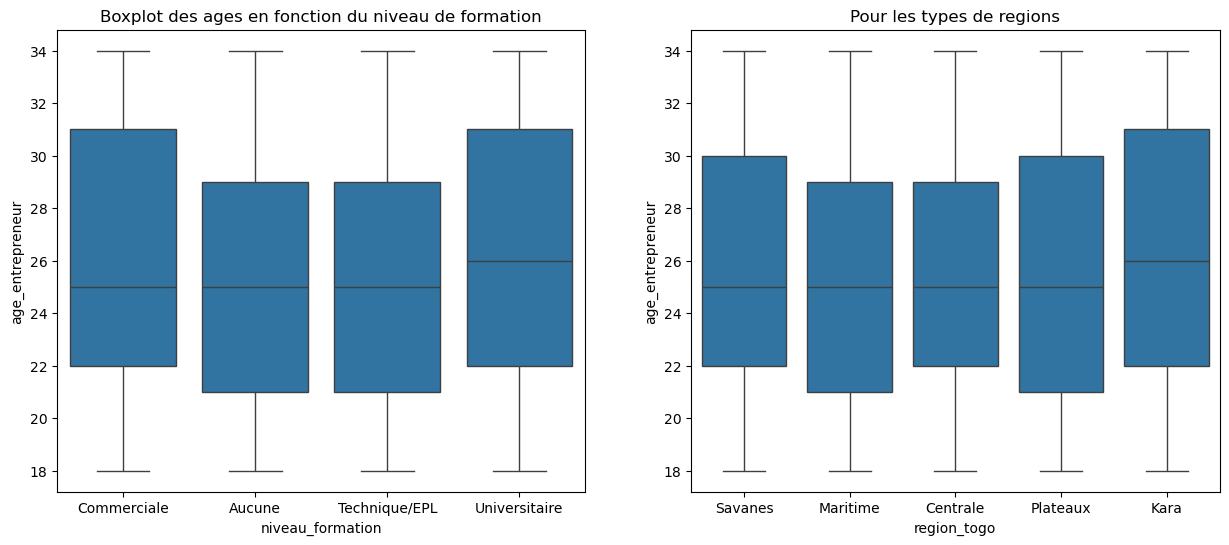

In [ ]:
plt.figure(figsize =(15,6))
plt.subplot(1,2,1)
plt.title("Boxplot des ages en fonction du niveau de formation")
sns.boxplot(data = df, y= df["age_entrepreneur"], x = "niveau_formation")

plt.subplot(1,2,2)
plt.title("Pour les types de regions")
sns.boxplot(data = df, x = "region_togo", y = "age_entrepreneur")

D'apres anlyse il n'a pas de valeurs aberantes dans la variable **age** quantitatives

- Verifions les outliers sur la variale **budget_demande_fcfa**

<Axes: title={'center': 'Pour les types de regions'}, xlabel='region_togo', ylabel='budget_demande_fcfa'>

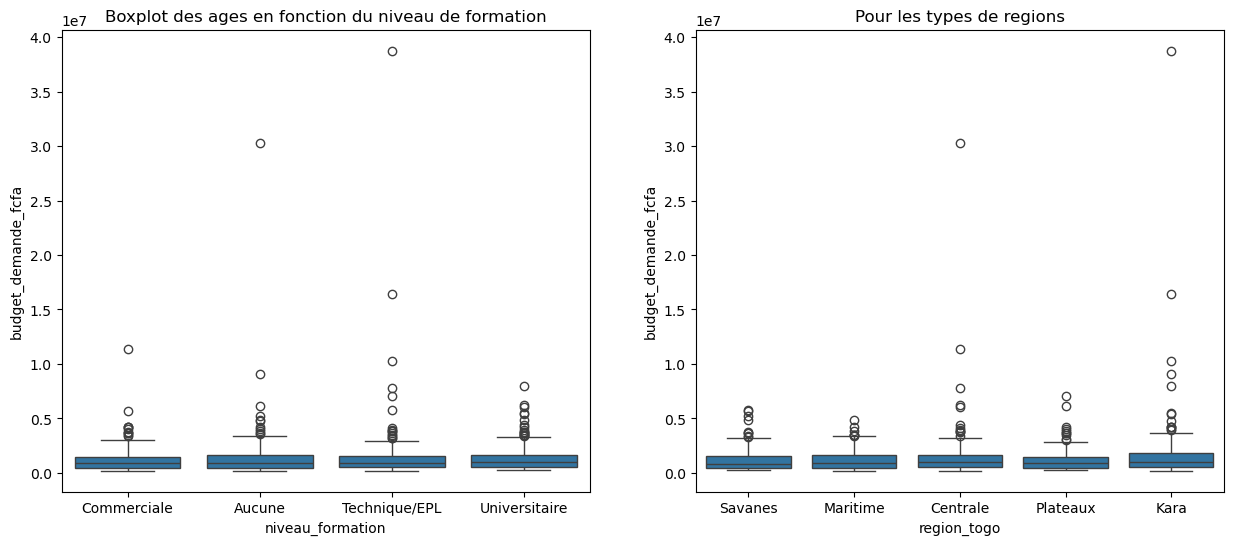

In [ ]:
plt.figure(figsize =(15,6))
plt.subplot(1,2,1)
plt.title("Boxplot des ages en fonction du niveau de formation")
sns.boxplot(data = df, y= df["budget_demande_fcfa"], x = "niveau_formation")

plt.subplot(1,2,2)
plt.title("Pour les types de regions")
sns.boxplot(data = df, x = "region_togo", y = "budget_demande_fcfa")

In [ ]:
# On trouve la valeur limite supérieure (99% des données sont en dessous)
limite_superieure = df['budget_demande_fcfa'].quantile(0.99)

# On applique le plafond
df['budget_demande_fcfa'] = df['budget_demande_fcfa'].clip(upper=limite_superieure)

<Axes: title={'center': 'Pour les types de regions'}, xlabel='region_togo', ylabel='budget_demande_fcfa'>

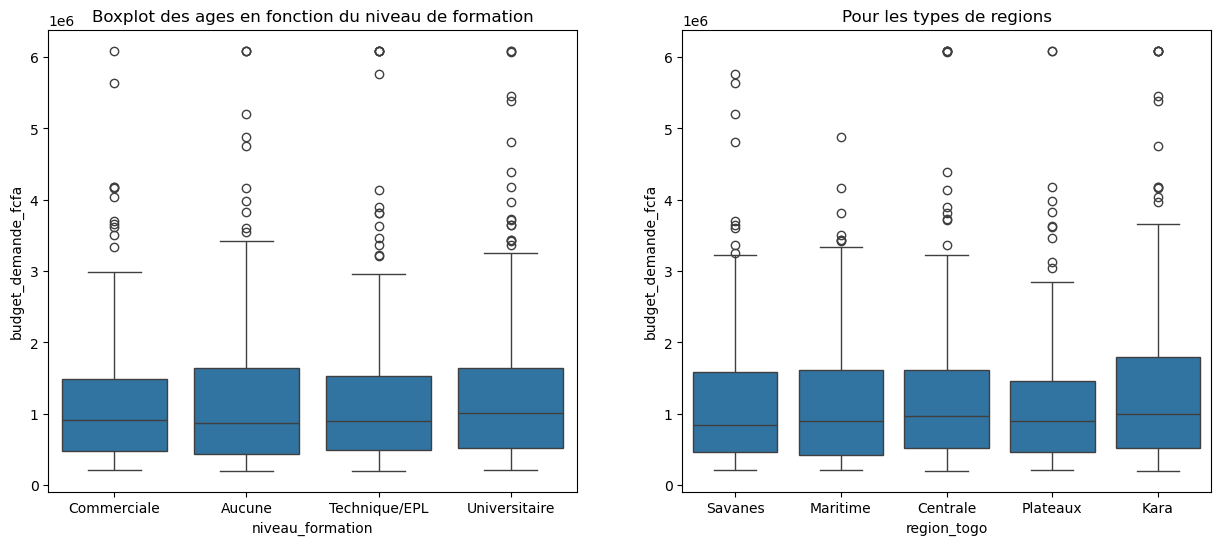

In [ ]:
plt.figure(figsize =(15,6))
plt.subplot(1,2,1)
plt.title("Boxplot des ages en fonction du niveau de formation")
sns.boxplot(data = df, y= df["budget_demande_fcfa"], x = "niveau_formation")

plt.subplot(1,2,2)
plt.title("Pour les types de regions")
sns.boxplot(data = df, x = "region_togo", y = "budget_demande_fcfa")

## Recherche de la realtion entre la variable cible et les autres

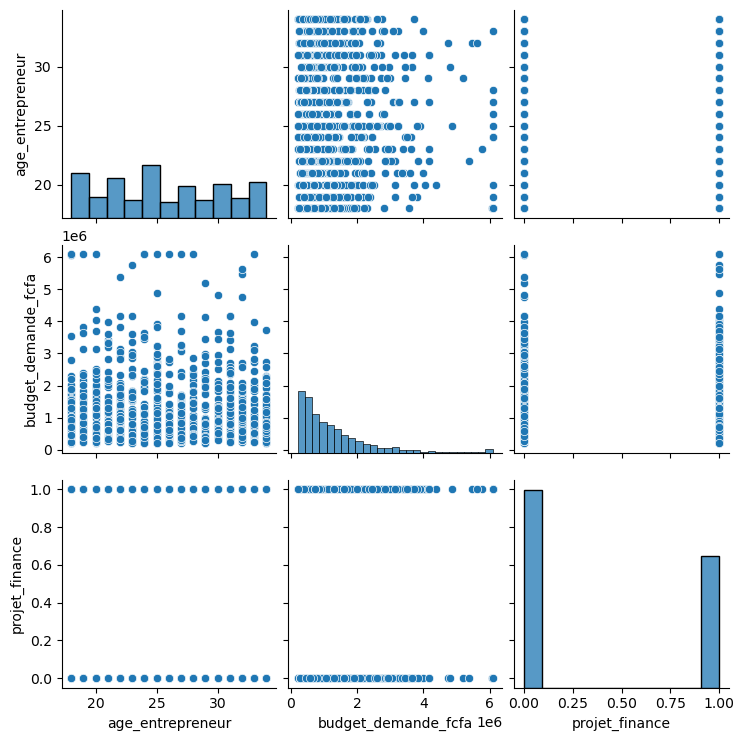

In [ ]:
sns.pairplot(df)

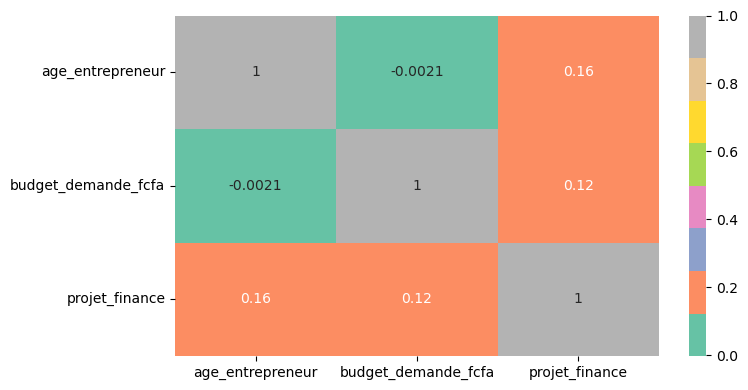

In [ ]:
plt.figure(figsize = (8,4))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = "Set2")
plt.xticks(rotation =0)
plt.tight_layout()

In [ ]:
X = df[["age_entrepreneur", "budget_demande_fcfa"]]
y = df.projet_finance

#### Decoupage du dataset

In [ ]:
X_train , X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)

print(f"donnees Entrainement : {X_train.shape}")
print(f"donnes Evaluation :{X_test.shape}")

donnees Entrainement : (800, 2)
donnes Evaluation :(200, 2)


## Modele 1 : K-NN

In [ ]:
# scaler = StandardScaler()
# # On ajuste le scaler sur le train set et on transforme
# X_train = scaler.fit_transform(X_train)

# X_test = scaler.transform(X_test)

In [ ]:
model_1 = KNeighborsClassifier()
model_1.fit(X_train, y_train)
model_1.score(X_train, y_train)

0.69375

In [ ]:
val_score = cross_val_score(model_1, X_train, y_train , cv = 5)
val_score.mean()

np.float64(0.56875)

- **Tracons la courbe de performance du ,model**

In [ ]:
train_score, val_score = validation_curve(model_1, X_train, y_train, param_name= "n_neighbors", param_range = np.arange(1, 50, 1), cv = 5)

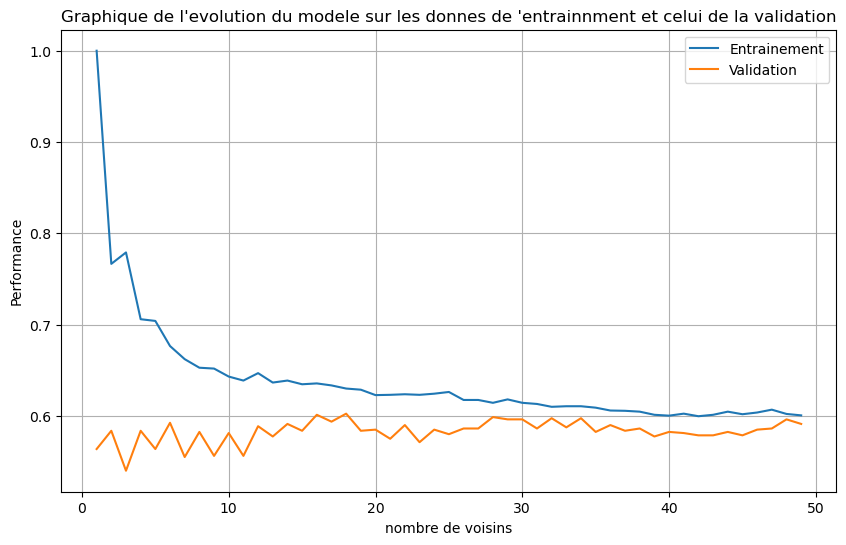

In [ ]:
plt.figure(figsize = (10, 6))
plt.title("Graphique de l'evolution du modele sur les donnes de 'entrainnment et celui de la validation")
plt.plot(np.arange(1,50,1), train_score.mean(axis = 1), label = "Entrainement")
plt.plot(np.arange(1,50,1), val_score.mean(axis = 1), label = "Validation")
plt.ylabel("Performance")
plt.grid()
plt.xlabel("nombre de voisins")
plt.legend()


### Recherche des meilleur hyperparametre du models

In [ ]:
grid_modele_1 = GridSearchCV(KNeighborsClassifier(), param_grid = {"n_neighbors":np.arange(1,20,1),
                                                       "metric" : ["manhattan", "eucludean"]
                                                      },cv = 5
)

In [ ]:
grid_modele_1.fit(X_train, y_train)#Entrainement sur le noiuveau modele
grid_modele_1.best_params_

c:\Users\dc\anaconda3\sante\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
95 fits failed out of a total of 190.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
95 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\dc\anaconda3\sante\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\dc\anaconda3\sante\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\dc\anaconda3\sante\Lib\site-packages\sklearn\base.py", line 436, in _validat

{'metric': 'manhattan', 'n_neighbors': np.int64(18)}

In [ ]:
print(f"Le score du modele sur les donnees de la validation : {round(grid_modele_1.best_score_,3)*100} %")

Le score du modele sur les donnees de la validation : 60.199999999999996 %


- Sur les donnnes de validation le score est : **60%**

#### Test du model sur les donnes de l'evaluation

In [ ]:
grid_modele_1.score(X_test, y_test)

0.62

- La performance du modele sur l'evaluation  : **35,5%**

In [ ]:
# Le modele perd sa puisssance sur les donnes qu'il n'a jamais vus 

In [ ]:
meilleur_modele= grid_modele_1.best_estimator_

In [ ]:
# 2. On calcule la courbe d'apprentissage sur le meilleur modèle (Beaucoup plus rapide !)
N, train_score, val_score = learning_curve(
    meilleur_modele, 
    X_train, 
    y_train, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=5,
    scoring='f1_weighted' # Utilise la métrique reine de la classification
)

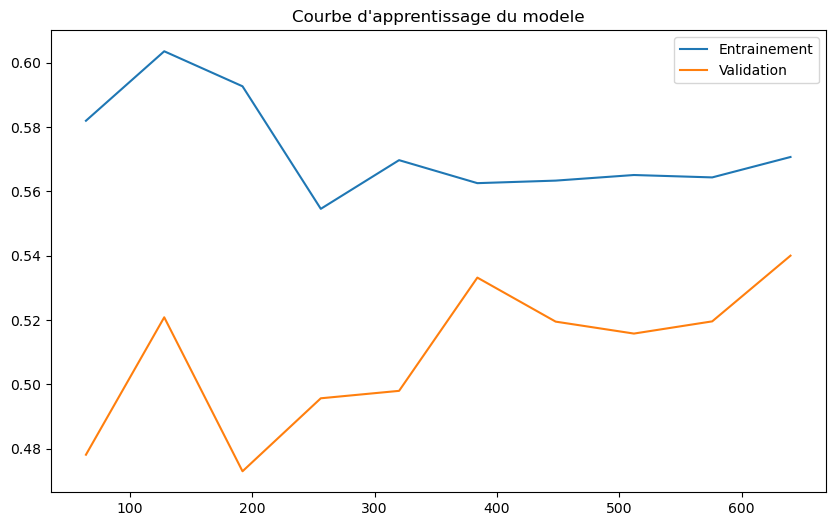

In [ ]:
plt.figure(figsize = (10, 6))
plt.title("Courbe d'apprentissage du modele")
plt.plot(N, train_score.mean(axis =1), label = "Entrainement")
plt.plot(N, val_score.mean(axis =1), label = "Validation")
plt.legend()

In [ ]:
confusion_matrix(y_test, meilleur_modele.predict(X_test))

array([[115,  14],
       [ 62,   9]])

In [ ]:
# Le souci esr que comme KNN calcule en fonction de la distance il n;a pas pus preidre pour les ages rien que pour les prix de conmmandes ?

<h3>Le model est mauvais on va tester le deuxieme modele </h3>

## Utilussions le deuxieme  de modele la logisticRegression

In [ ]:
model_2 = LogisticRegression()

2026-09-07 14:38:15.032 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-07 14:38:16.697 
  command:

    streamlit run C:\Users\dc\anacondau\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-07 14:38:16.700 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-07 14:38:16.703 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-07 14:38:16.706 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-07 14:38:16.709 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-07 14:38:16.712 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-07 14:38:16.714 Session state does not fun

DeltaGenerator()